<class 'pandas.core.frame.DataFrame'>
Index: 2161 entries, 1 to 2185
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region           2161 non-null   object 
 1   year             2161 non-null   int64  
 2   grp_per_capita   2161 non-null   float64
 3   region_standard  2161 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 84.4+ KB
None

Missing values by column:
 region             0
year               0
grp_per_capita     0
region_standard    0
dtype: int64

Number of unique regions: 85
Number of unique years: 25

Summary statistics for GRP per capita:
 count    2.161000e+03
mean     2.583894e+05
std      5.331993e+05
min      0.000000e+00
25%      3.301230e+04
50%      1.318878e+05
75%      2.954355e+05
max      7.530485e+06
Name: grp_per_capita, dtype: float64


<Figure size 1600x600 with 0 Axes>

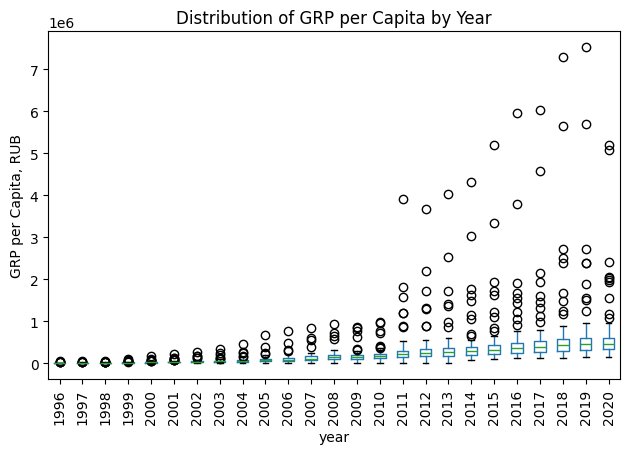

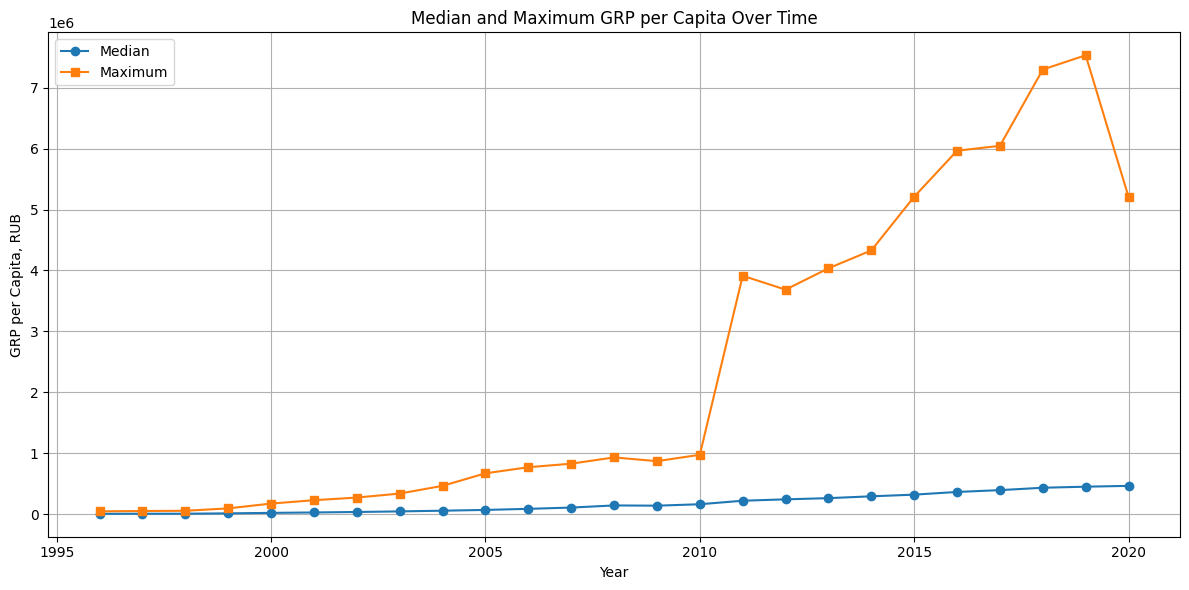


Top-10 regions by average GRP per capita:
 region_standard
Ненецкий автономный округ            2.313806e+06
Ямало-Ненецкий автономный округ      1.640577e+06
Ханты-Мансийский автономный округ    8.805455e+05
Сахалинская область                  8.607333e+05
Чукотский автономный округ           7.241227e+05
Москва                               6.667757e+05
Тюменская область                    6.427305e+05
Магаданская область                  4.885209e+05
Республика Саха (Якутия)             4.455480e+05
Санкт-Петербург                      3.554944e+05
Name: grp_per_capita, dtype: float64


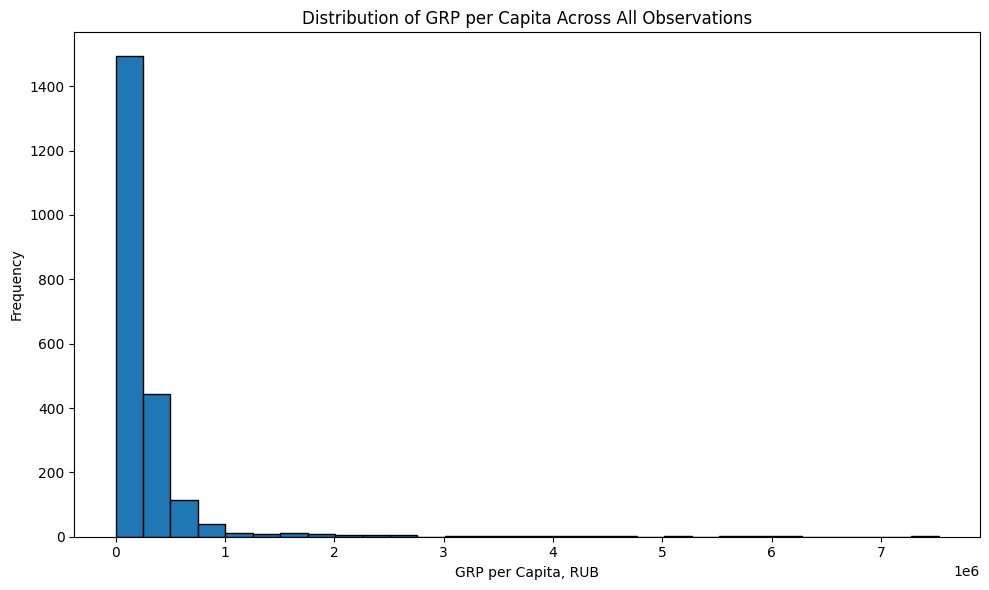

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/gross_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()].copy()

# 3. Rename columns for readability
df = df.rename(columns={
    "Год": "year",
    "ВРП_на_душу": "grp_per_capita"
})

# 4. Check data types and missing values
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())

# 5. Number of unique regions and years
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 6. Summary statistics for GRP per capita
print("\nSummary statistics for GRP per capita:\n", df["grp_per_capita"].describe())

# 7. Median and maximum trends over time
median_grp = df.groupby("year")["grp_per_capita"].median()
max_grp = df.groupby("year")["grp_per_capita"].max()

# 8. Boxplot by year
plt.figure(figsize=(16,6))
df.boxplot(column="grp_per_capita", by="year", grid=False, rot=90)
plt.title("Distribution of GRP per Capita by Year")
plt.suptitle("")
plt.ylabel("GRP per Capita, RUB")
plt.tight_layout()
plt.show()

# 9. Trend lines
plt.figure(figsize=(12,6))
plt.plot(median_grp.index, median_grp.values, marker="o", label="Median")
plt.plot(max_grp.index, max_grp.values, marker="s", label="Maximum")
plt.title("Median and Maximum GRP per Capita Over Time")
plt.xlabel("Year")
plt.ylabel("GRP per Capita, RUB")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Top-10 regions by average GRP per capita
top10 = (
    df.groupby("region_standard")["grp_per_capita"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop-10 regions by average GRP per capita:\n", top10)

# 11. Distribution histogram
plt.figure(figsize=(10,6))
plt.hist(df["grp_per_capita"], bins=30, edgecolor="black")
plt.title("Distribution of GRP per Capita Across All Observations")
plt.xlabel("GRP per Capita, RUB")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `gross_standardized.csv`

## Data Description
- The dataset contains 2,161 observations across 85 regions.
- Time coverage: 1996–2020.
- Key variable: gross regional product (GRP) per capita, measured in RUB.

---

## Data Types
- All variables are correctly formatted:
  - `year`: int64  
  - `grp_per_capita`: float64  
  - `region_standard`: object  

---

## Missing Values
- No missing values remain after filtering.

---

## Duplicates
- No duplicate records were found.

---

## Summary Statistics
- Mean: ~258,000 RUB  
- Median: ~131,900 RUB  
- Maximum: ~7,530,000 RUB  
- 75% of observations are below ~295,400 RUB  
- Minimum: 0 RUB  

The large gap between mean and median indicates a strongly right-skewed distribution driven by a small number of high-value regions.

---

## Trends Over Time
- The median GRP per capita shows steady growth, reflecting overall economic development.  
- The maximum values increase significantly, particularly in the 2000s and 2010s.  
- The gap between median and maximum widens over time, indicating increasing regional inequality.  

---

## Distribution Patterns
- Boxplots by year reveal a persistent right-skewed distribution with a long upper tail.  
- Most regions are concentrated below ~300,000 RUB, while a few regions exhibit extremely high values.  

---

## Outliers
- Extremely high values (above 1 million RUB) are present.  
- These correspond primarily to resource-rich regions (e.g., oil and gas production).  
- These observations are retained, as they reflect real structural economic differences.  

---

## Interpretation
- GRP per capita highlights strong economic inequality across regions.  
- A small number of regions dominate economic output, likely due to natural resources or industrial concentration.  
- The widening gap over time suggests that regional disparities are persistent and possibly increasing.  

This makes GRP per capita a key feature for distinguishing structurally different regions in clustering.

---

## Modeling Considerations
- Due to strong skewness, transformation (e.g., logarithmic scaling) or robust methods may be required.  
- Extreme values should be handled carefully, as they carry meaningful economic information rather than noise.  

---

## Conclusion
The dataset is clean and suitable for further analysis.

GRP per capita captures a fundamental dimension of regional economic structure and is expected to play a central role in clustering and identifying socio-economic groups.

In [ ]:
df.to_csv("../../data/clean/gross_AfterEDA.csv", index=False)